<a href="https://colab.research.google.com/github/MLfinal/Walmart-Recruiting---Store-Sales-Forecasting/blob/dev/models/tree_based/xgboost/model_experiment_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Walmart Store Sales — engineered XGBoost experiment

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MLfinal/Walmart-Recruiting---Store-Sales-Forecasting/blob/dev/models/tree_based/xgboost/model_experiment_XGBoost.ipynb)

This notebook extends `baseline_xgboost.ipynb` with the feature families documented for the LightGBM experiment, chronological validation, Optuna tuning, and extensive Weights & Biases tracking.

Important leakage rule: short target lags (`lag_1`, `lag_4`, `lag_13`) are not used because the Kaggle test set is a 39-week multi-step horizon. `lag_52` is safe here: every validation/test value comes from already observed history. Training target aggregates are shifted expanding statistics; validation/test aggregates are learned only from their historical training partition.

The notebook is intentionally saved without outputs. In Colab, select a GPU runtime, set `WANDB_API_KEY` in Colab Secrets, update `DATA_DIR` if necessary, and run all cells.

In [1]:
%pip install -q "xgboost>=3.0,<4" "wandb>=0.19,<1" "optuna>=4.0,<5" "joblib>=1.4,<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 24.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from __future__ import annotations

import json
import math
import os
import platform
import random
import subprocess
import uuid
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import sklearn
import wandb
import xgboost as xgb
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error
from wandb.integration.xgboost import WandbCallback

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
pd.set_option("display.max_columns", 120)

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "xgboost": xgb.__version__,
    "optuna": optuna.__version__,
    "wandb": wandb.__version__,
})

{'python': '3.12.13', 'pandas': '2.2.2', 'scikit_learn': '1.6.1', 'xgboost': '3.3.0', 'optuna': '4.9.0', 'wandb': '0.28.0'}


## Configuration

`RUN_TUNING` and `RUN_FINAL_REFIT` are explicit switches so expensive stages are easy to control. The default is a complete experiment. Set `DEVICE="cpu"` if the Colab runtime has no GPU.

In [4]:
DATA_DIR = Path("/content/drive/MyDrive/walmart_competition_data")
OUTPUT_DIR = Path("/content/artifacts/xgboost_engineered")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

WANDB_ENTITY = "kende23-n-a"  # set to None to use your default W&B entity
WANDB_PROJECT = "Walmart-Recruiting---Store-Sales-Forecasting"
EXPERIMENT_ID = f"xgb-engineered-{uuid.uuid4().hex[:8]}"

CONFIG = {
    "seed": SEED,
    "validation_weeks": 52,
    "holiday_weight": 5.0,
    "objective": "reg:absoluteerror",
    "eval_metric": "mae",
    "tree_method": "hist",
    "device": "cuda",
    "early_stopping_rounds": 100,
    "max_estimators": 3000,
    "tuning_trials": 20,
    "tuning_timeout_seconds": None,
    "run_tuning": True,
    "run_final_refit": True,
    "log_raw_dataset_artifact": True,
    "log_full_validation_predictions": True,
}

# Prefer a Colab Secret named WANDB_API_KEY; environment variables also work.
try:
    from google.colab import userdata
    api_key = userdata.get("WANDB_API_KEY")
except Exception:
    api_key = os.environ.get("WANDB_API_KEY")
wandb.login(key=api_key, relogin=False) if api_key else wandb.login()

CONFIG

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


{'seed': 42,
 'validation_weeks': 52,
 'holiday_weight': 5.0,
 'objective': 'reg:absoluteerror',
 'eval_metric': 'mae',
 'tree_method': 'hist',
 'device': 'cuda',
 'early_stopping_rounds': 100,
 'max_estimators': 3000,
 'tuning_trials': 20,
 'tuning_timeout_seconds': None,
 'run_tuning': True,
 'run_final_refit': True,
 'log_raw_dataset_artifact': True,
 'log_full_validation_predictions': True}

## Load, validate, and merge the four competition tables

In [5]:
required_files = ["train.csv", "test.csv", "features.csv", "stores.csv"]
missing_files = [name for name in required_files if not (DATA_DIR / name).exists()]
assert not missing_files, f"Missing files in {DATA_DIR}: {missing_files}"

train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"])
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])
features_raw = pd.read_csv(DATA_DIR / "features.csv", parse_dates=["Date"])
stores_raw = pd.read_csv(DATA_DIR / "stores.csv")

assert {"Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"}.issubset(train_raw.columns)
assert {"Store", "Dept", "Date", "IsHoliday"}.issubset(test_raw.columns)
assert {"Store", "Date", "IsHoliday"}.issubset(features_raw.columns)
assert {"Store", "Type", "Size"}.issubset(stores_raw.columns)
assert not train_raw.duplicated(["Store", "Dept", "Date"]).any()
assert not test_raw.duplicated(["Store", "Dept", "Date"]).any()
assert not features_raw.duplicated(["Store", "Date"]).any()


def merge_tables(sales: pd.DataFrame) -> pd.DataFrame:
    # Keep the authoritative holiday flag from train/test.
    external = features_raw.drop(columns="IsHoliday")
    merged = sales.merge(external, on=["Store", "Date"], how="left", validate="many_to_one")
    merged = merged.merge(stores_raw, on="Store", how="left", validate="many_to_one")
    return merged.sort_values(["Date", "Store", "Dept"]).reset_index(drop=True)


train_merged = merge_tables(train_raw)
test_merged = merge_tables(test_raw)

profile = pd.DataFrame({
    "table": ["train", "test", "features", "stores"],
    "rows": [len(train_raw), len(test_raw), len(features_raw), len(stores_raw)],
    "columns": [train_raw.shape[1], test_raw.shape[1], features_raw.shape[1], stores_raw.shape[1]],
    "min_date": [train_raw.Date.min(), test_raw.Date.min(), features_raw.Date.min(), pd.NaT],
    "max_date": [train_raw.Date.max(), test_raw.Date.max(), features_raw.Date.max(), pd.NaT],
})
display(profile)

,table,rows,columns,min_date,max_date
0,train,421570,5,2010-02-05,2012-10-26
1,test,115064,4,2012-11-02,2013-07-26
2,features,8190,12,2010-02-05,2013-07-26
3,stores,45,3,NaT,NaT


## Leakage-safe feature engineering

The static transformer learns numeric imputations from its fit partition. It creates calendar, cyclical, named-holiday, holiday-proximity, markdown, store metadata, and categorical interaction features. IDs are stable integers so train, validation, final refit, and Kaggle test use identical encodings.

In [6]:
MARKDOWN_COLS = ("MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5")
IMPUTE_COLS = ("CPI", "Unemployment", "Temperature", "Fuel_Price")
TYPE_MAP = {"A": 0, "B": 1, "C": 2}
HOLIDAY_DATES = {
    "SuperBowl": ("2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08"),
    "LaborDay": ("2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06"),
    "Thanksgiving": ("2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29"),
    "Christmas": ("2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27"),
}


class WalmartKnownFeatureTransformer(BaseEstimator, TransformerMixin):
    """Features known at forecast time; fit stores train-only imputation values."""

    def fit(self, X: pd.DataFrame, y=None):
        self.numeric_fill_values_ = {
            col: float(X[col].median()) for col in IMPUTE_COLS if col in X.columns
        }
        self.start_date_ = pd.Timestamp("2010-02-05")
        self.holiday_dates_ = {
            name: pd.to_datetime(list(dates)) for name, dates in HOLIDAY_DATES.items()
        }
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        frame = X.copy()
        frame["Date"] = pd.to_datetime(frame["Date"])

        for col in MARKDOWN_COLS:
            frame[f"{col}_missing"] = frame[col].isna().astype("int8")
            frame[col] = frame[col].fillna(0.0).astype("float32")
        for col, value in self.numeric_fill_values_.items():
            frame[col] = frame[col].fillna(value).astype("float32")

        date = frame["Date"]
        iso_week = date.dt.isocalendar().week.astype("int16")
        frame["Year"] = date.dt.year.astype("int16")
        frame["Month"] = date.dt.month.astype("int8")
        frame["WeekOfYear"] = iso_week.astype("int8")
        frame["Quarter"] = date.dt.quarter.astype("int8")
        frame["DayOfYear"] = date.dt.dayofyear.astype("int16")
        frame["DaysFromStart"] = (date - self.start_date_).dt.days.astype("int16")
        frame["WeekSin"] = np.sin(2 * np.pi * iso_week / 52.0).astype("float32")
        frame["WeekCos"] = np.cos(2 * np.pi * iso_week / 52.0).astype("float32")
        frame["MonthSin"] = np.sin(2 * np.pi * frame["Month"] / 12.0).astype("float32")
        frame["MonthCos"] = np.cos(2 * np.pi * frame["Month"] / 12.0).astype("float32")

        for name, holiday_dates in self.holiday_dates_.items():
            frame[f"Is{name}Week"] = date.isin(holiday_dates).astype("int8")
            distances = np.column_stack([(date - holiday).dt.days.to_numpy() for holiday in holiday_dates])
            nearest = distances[np.arange(len(frame)), np.abs(distances).argmin(axis=1)]
            frame[f"DaysToNearest{name}"] = nearest.astype("int16")
            frame[f"AbsWeeksToNearest{name}"] = (np.abs(nearest) / 7.0).astype("float32")

        frame["TotalMarkDown"] = frame[list(MARKDOWN_COLS)].sum(axis=1).astype("float32")
        for col in MARKDOWN_COLS:
            frame[f"Has{col}"] = (frame[col] > 0).astype("int8")
            frame[f"{col}_log1p"] = np.log1p(frame[col].clip(lower=0)).astype("float32")
            frame[f"Holiday_{col}"] = (frame["IsHoliday"].astype("int8") * frame[col]).astype("float32")
        frame["HasAnyMarkDown"] = (frame["TotalMarkDown"] > 0).astype("int8")
        frame["TotalMarkDown_log1p"] = np.log1p(frame["TotalMarkDown"].clip(lower=0)).astype("float32")
        frame["Holiday_TotalMarkDown"] = (
            frame["IsHoliday"].astype("int8") * frame["TotalMarkDown"]
        ).astype("float32")

        frame["Type"] = frame["Type"].map(TYPE_MAP).fillna(-1).astype("int8")
        frame["IsHoliday"] = frame["IsHoliday"].astype("int8")
        frame["Store_Dept"] = (frame["Store"].astype("int32") * 1000 + frame["Dept"]).astype("int32")
        frame["Type_Dept"] = (frame["Type"].astype("int32") * 1000 + frame["Dept"]).astype("int32")
        frame["Size_log1p"] = np.log1p(frame["Size"]).astype("float32")
        return frame


class TimeSafeTargetAggregateEncoder(BaseEstimator, TransformerMixin):
    """Shifted expanding encodings for fit rows; train-only mappings for future rows."""

    def __init__(self, groupings=(("Store",), ("Dept",), ("Store", "Dept"), ("Type", "Dept"))):
        self.groupings = groupings

    @staticmethod
    def _prefix(cols):
        return "_".join(cols) + "_Sales"

    def fit(self, X: pd.DataFrame, y=None):
        frame = X.copy()
        if y is not None:
            frame["Weekly_Sales"] = np.asarray(y)
        self.global_stats_ = frame["Weekly_Sales"].agg(["mean", "median", "std"]).to_dict()
        self.maps_ = {}
        for cols in self.groupings:
            self.maps_[cols] = frame.groupby(list(cols), observed=True)["Weekly_Sales"].agg(
                ["mean", "median", "std", "count"]
            )
        return self

    def fit_transform(self, X: pd.DataFrame, y=None, **fit_params):
        frame = X.copy()
        if y is not None:
            frame["Weekly_Sales"] = np.asarray(y)
        frame["__original_order"] = np.arange(len(frame))
        frame = frame.sort_values(["Date", "Store", "Dept"]).copy()
        for cols in self.groupings:
            grouped = frame.groupby(list(cols), observed=True, sort=False)["Weekly_Sales"]
            prefix = self._prefix(cols)
            frame[f"{prefix}_mean"] = grouped.transform(
                lambda s: s.shift(1).expanding(min_periods=1).mean()
            ).astype("float32")
            frame[f"{prefix}_median"] = grouped.transform(
                lambda s: s.shift(1).expanding(min_periods=1).median()
            ).astype("float32")
            frame[f"{prefix}_std"] = grouped.transform(
                lambda s: s.shift(1).expanding(min_periods=2).std()
            ).astype("float32")
            frame[f"{prefix}_count"] = frame.groupby(list(cols), observed=True, sort=False).cumcount().astype("int32")
        frame = frame.sort_values("__original_order").drop(columns="__original_order").reset_index(drop=True)
        self.fit(X, y)
        return frame

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        frame = X.copy().reset_index(drop=True)
        for cols, mapping in self.maps_.items():
            prefix = self._prefix(cols)
            keys = frame[list(cols)] if len(cols) > 1 else frame[cols[0]]
            for stat in ["mean", "median", "std", "count"]:
                values = mapping[stat]
                if len(cols) > 1:
                    lookup_keys = pd.MultiIndex.from_frame(keys)
                    encoded = values.reindex(lookup_keys).to_numpy()
                else:
                    encoded = keys.map(values).to_numpy()
                fallback = self.global_stats_.get(stat, 0.0) if stat != "count" else 0
                frame[f"{prefix}_{stat}"] = pd.Series(encoded).fillna(fallback).to_numpy()
        return frame

In [7]:
def add_safe_lag_52(frame: pd.DataFrame, observed_history: pd.DataFrame) -> pd.DataFrame:
    """Join sales exactly 52 weeks earlier from rows whose target is observed."""
    history = observed_history[["Store", "Dept", "Date", "Weekly_Sales"]].copy()
    history["Date"] = pd.to_datetime(history["Date"]) + pd.Timedelta(weeks=52)
    history = history.rename(columns={"Weekly_Sales": "SalesLag52"})
    result = frame.merge(history, on=["Store", "Dept", "Date"], how="left", validate="many_to_one")
    result["SalesLag52_available"] = result["SalesLag52"].notna().astype("int8")
    return result


def weighted_mae(y_true, y_pred, is_holiday, holiday_weight=5.0) -> float:
    weights = np.where(np.asarray(is_holiday, dtype=bool), holiday_weight, 1.0)
    return float(np.average(np.abs(np.asarray(y_true) - np.asarray(y_pred)), weights=weights))


def competition_weights(is_holiday) -> np.ndarray:
    return np.where(np.asarray(is_holiday, dtype=bool), CONFIG["holiday_weight"], 1.0)


def model_matrix(frame: pd.DataFrame, feature_columns: list[str] | None = None):
    excluded = {"Date", "Weekly_Sales"}
    columns = feature_columns or [col for col in frame.columns if col not in excluded]
    matrix = frame[columns].copy()
    bad = matrix.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()
    assert not bad, f"Non-numeric model columns: {bad}"
    return matrix, columns

## Chronological split and matrix construction

The final 52 distinct weeks are validation. All transformer fitting and target-derived validation features use only earlier rows.

In [8]:
unique_dates = np.sort(train_merged["Date"].unique())
assert len(unique_dates) > CONFIG["validation_weeks"]
validation_start = pd.Timestamp(unique_dates[-CONFIG["validation_weeks"]])
train_mask = train_merged["Date"] < validation_start
valid_mask = ~train_mask
train_part = train_merged.loc[train_mask].reset_index(drop=True)
valid_part = train_merged.loc[valid_mask].reset_index(drop=True)
assert train_part.Date.max() < valid_part.Date.min()

known_transformer = WalmartKnownFeatureTransformer()
train_engineered = known_transformer.fit_transform(train_part)
valid_engineered = known_transformer.transform(valid_part)
train_engineered = add_safe_lag_52(train_engineered, train_part)
valid_engineered = add_safe_lag_52(valid_engineered, train_part)

aggregate_encoder = TimeSafeTargetAggregateEncoder()
train_engineered = aggregate_encoder.fit_transform(
    train_engineered, train_engineered["Weekly_Sales"]
)
valid_engineered = aggregate_encoder.transform(valid_engineered)

X_train, FEATURE_COLUMNS = model_matrix(train_engineered)
X_valid, _ = model_matrix(valid_engineered, FEATURE_COLUMNS)
y_train = train_engineered["Weekly_Sales"].astype("float32")
y_valid = valid_engineered["Weekly_Sales"].astype("float32")
w_train = competition_weights(train_engineered["IsHoliday"])
w_valid = competition_weights(valid_engineered["IsHoliday"])

assert X_train.columns.tolist() == X_valid.columns.tolist()
assert np.isfinite(y_train).all() and np.isfinite(y_valid).all()

split_summary = {
    "train_rows": len(X_train),
    "valid_rows": len(X_valid),
    "train_start": str(train_part.Date.min().date()),
    "train_end": str(train_part.Date.max().date()),
    "valid_start": str(valid_part.Date.min().date()),
    "valid_end": str(valid_part.Date.max().date()),
    "feature_count": len(FEATURE_COLUMNS),
    "train_lag52_coverage": float(train_engineered["SalesLag52_available"].mean()),
    "valid_lag52_coverage": float(valid_engineered["SalesLag52_available"].mean()),
}

missingness = (
    X_train.isna().mean().rename("train_missing_rate").to_frame()
    .join(X_valid.isna().mean().rename("valid_missing_rate"))
    .reset_index(names="feature")
    .sort_values("train_missing_rate", ascending=False)
)
display(pd.Series(split_summary, name="value").to_frame())
display(missingness.head(20))

,value
train_rows,267184
valid_rows,154386
train_start,2010-02-05
train_end,2011-10-28
valid_start,2011-11-04
valid_end,2012-10-26
feature_count,81
train_lag52_coverage,0.417757
valid_lag52_coverage,0.971092


,feature,train_missing_rate,valid_missing_rate
63,SalesLag52,0.582243,0.028908
75,Store_Dept_Sales_std,0.024234,0.000000
74,Store_Dept_Sales_median,0.012179,0.000000
73,Store_Dept_Sales_mean,0.012179,0.000000
79,Type_Dept_Sales_std,0.001684,0.000000
77,Type_Dept_Sales_mean,0.000846,0.000000
78,Type_Dept_Sales_median,0.000846,0.000000
71,Dept_Sales_std,0.000606,0.000000
67,Store_Sales_std,0.000337,0.000000
70,Dept_Sales_median,0.000303,0.000000


## Log data lineage and feature metadata to W&B

In [9]:
prep_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name=f"{EXPERIMENT_ID}-data-and-features",
    group=EXPERIMENT_ID,
    job_type="data-preparation",
    tags=["xgboost", "feature-engineering", "time-split", "wmae"],
    config={**CONFIG, **split_summary},
    save_code=True,
)
prep_run.log({
    "data/profile": wandb.Table(dataframe=profile.astype(str)),
    "features/missingness": wandb.Table(dataframe=missingness),
    "features/count": len(FEATURE_COLUMNS),
    "split/train_rows": len(X_train),
    "split/valid_rows": len(X_valid),
    "split/valid_lag52_coverage": split_summary["valid_lag52_coverage"],
})

feature_manifest_path = OUTPUT_DIR / "feature_columns.json"
feature_manifest_path.write_text(json.dumps(FEATURE_COLUMNS, indent=2))
split_path = OUTPUT_DIR / "split_summary.json"
split_path.write_text(json.dumps(split_summary, indent=2))

feature_artifact = wandb.Artifact(
    f"{EXPERIMENT_ID}-feature-manifest",
    type="feature-manifest",
    metadata=split_summary,
)
feature_artifact.add_file(str(feature_manifest_path))
feature_artifact.add_file(str(split_path))
prep_run.log_artifact(feature_artifact, aliases=["latest"])

if CONFIG["log_raw_dataset_artifact"]:
    dataset_artifact = wandb.Artifact(
        "walmart-recruiting-raw-data",
        type="dataset",
        description="Raw Kaggle Walmart Store Sales CSV tables.",
        metadata={"source": "kaggle", **split_summary},
    )
    for filename in required_files:
        dataset_artifact.add_file(str(DATA_DIR / filename), name=filename)
    prep_run.log_artifact(dataset_artifact, aliases=["latest"])
prep_run.finish()

wandb: WARNING Artifact "walmart-recruiting-raw-data" already exists with the same content. No new version will be created.


features/count,▁
split/train_rows,▁
split/valid_lag52_coverage,▁
split/valid_rows,▁
features/count,81
split/train_rows,267184
split/valid_lag52_coverage,0.97109
split/valid_rows,154386


## Median sanity benchmark

In [10]:
pair_median = train_part.groupby(["Store", "Dept"])["Weekly_Sales"].median()
dept_median = train_part.groupby("Dept")["Weekly_Sales"].median()
global_median = float(train_part["Weekly_Sales"].median())
valid_keys = valid_part[["Store", "Dept"]]
naive_pred = pd.Series(
    [pair_median.get((s, d), np.nan) for s, d in valid_keys.itertuples(index=False)],
    index=valid_keys.index,
).fillna(valid_keys["Dept"].map(dept_median)).fillna(global_median)
naive_wmae = weighted_mae(
    y_valid, naive_pred, valid_engineered["IsHoliday"], CONFIG["holiday_weight"]
)
print(f"Median benchmark validation WMAE: {naive_wmae:,.2f}")

Median benchmark validation WMAE: 3,305.52


## Optuna hyperparameter tuning with one W&B run per trial

Every trial logs its sampled configuration, per-boosting-round metrics through `WandbCallback`, final metrics, best iteration, and state. Failed trials are marked in W&B and do not leave an open run.

In [11]:
def suggest_params(trial: optuna.Trial) -> dict:
    return {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 20.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-8, 5.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 20.0, log=True),
        "max_bin": trial.suggest_categorical("max_bin", [128, 256, 512]),
    }


def make_model(params: dict, callbacks=None, n_estimators=None, early_stopping=True):
    model_params = {
        "objective": CONFIG["objective"],
        "eval_metric": CONFIG["eval_metric"],
        "tree_method": CONFIG["tree_method"],
        "device": CONFIG["device"],
        "n_estimators": n_estimators or CONFIG["max_estimators"],
        "random_state": CONFIG["seed"],
        "n_jobs": -1,
        **params,
    }
    if early_stopping:
        model_params["early_stopping_rounds"] = CONFIG["early_stopping_rounds"]
    if callbacks:
        model_params["callbacks"] = callbacks
    return xgb.XGBRegressor(**model_params)


def objective(trial: optuna.Trial) -> float:
    params = suggest_params(trial)
    trial_run = wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name=f"{EXPERIMENT_ID}-trial-{trial.number:03d}",
        group=EXPERIMENT_ID,
        job_type="hyperparameter-tuning",
        tags=["xgboost", "optuna", "trial", "time-split", "wmae"],
        config={**CONFIG, **split_summary, **params, "trial_number": trial.number},
        save_code=True,
    )
    try:
        callback = WandbCallback(
            log_model=False,
            log_feature_importance=False,
            define_metric=True,
        )
        candidate = make_model(params, callbacks=[callback])
        candidate.fit(
            X_train,
            y_train,
            sample_weight=w_train,
            eval_set=[(X_train, y_train), (X_valid, y_valid)],
            sample_weight_eval_set=[w_train, w_valid],
            verbose=False,
        )
        pred = candidate.predict(X_valid)
        score = weighted_mae(y_valid, pred, valid_engineered["IsHoliday"])
        mae = float(mean_absolute_error(y_valid, pred))
        rmse = float(math.sqrt(mean_squared_error(y_valid, pred)))
        trial.set_user_attr("best_iteration", int(candidate.best_iteration))
        trial.set_user_attr("mae", mae)
        trial.set_user_attr("rmse", rmse)
        trial_run.log({
            "validation/wmae": score,
            "validation/mae": mae,
            "validation/rmse": rmse,
            "model/best_iteration": int(candidate.best_iteration),
            "model/best_score": float(candidate.best_score),
        })
        trial_run.summary.update({
            "validation/wmae": score,
            "validation/mae": mae,
            "validation/rmse": rmse,
            "model/best_iteration": int(candidate.best_iteration),
            "trial/state": "COMPLETE",
        })
        return score
    except Exception as exc:
        trial_run.summary.update({"trial/state": "FAILED", "trial/error": repr(exc)})
        raise
    finally:
        trial_run.finish()


if CONFIG["run_tuning"]:
    sampler = optuna.samplers.TPESampler(seed=CONFIG["seed"], multivariate=True)
    study = optuna.create_study(
        direction="minimize",
        sampler=sampler,
        study_name=EXPERIMENT_ID,
    )
    study.optimize(
        objective,
        n_trials=CONFIG["tuning_trials"],
        timeout=CONFIG["tuning_timeout_seconds"],
        gc_after_trial=True,
    )
    BEST_PARAMS = study.best_trial.params
    BEST_TUNING_ITERATION = int(study.best_trial.user_attrs["best_iteration"])
else:
    # Reasonable baseline-derived fallback when tuning is intentionally disabled.
    BEST_PARAMS = {
        "learning_rate": 0.03, "max_depth": 8, "min_child_weight": 5.0,
        "subsample": 0.85, "colsample_bytree": 0.85, "gamma": 0.0,
        "reg_alpha": 0.0, "reg_lambda": 1.0, "max_bin": 256,
    }
    BEST_TUNING_ITERATION = 1500

BEST_PARAMS

/tmp/ipykernel_4867/2046823489.py:90: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(seed=CONFIG["seed"], multivariate=True)
[I 2026-07-06 17:11:11,461] A new study created in memory with name: xgb-engineered-25de6b22


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [17:12:31] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


best_iteration,▁
best_score,▁
epoch,▁▁▁▁▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇███
model/best_iteration,▁
model/best_score,▁
validation/mae,▁
validation/rmse,▁
validation/wmae,▁
validation_0-mae,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-mae,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,2219


[I 2026-07-06 17:12:34,974] Trial 0 finished with value: 1935.9731155567185 and parameters: {'learning_rate': 0.02536276934555762, 'max_depth': 12, 'min_child_weight': 8.960785365368121, 'subsample': 0.8595304694689628, 'colsample_bytree': 0.7046065241548528, 'gamma': 2.275053705838343e-07, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 9.842315738502599, 'max_bin': 256}. Best is trial 0 with value: 1935.9731155567185.


best_iteration,▁
best_score,▁
epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇████
model/best_iteration,▁
model/best_score,▁
validation/mae,▁
validation/rmse,▁
validation/wmae,▁
validation_0-mae,█▅▄▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-mae,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,245


...

best_iteration,▁
best_score,▁
epoch,▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇████
model/best_iteration,▁
model/best_score,▁
validation/mae,▁
validation/rmse,▁
validation/wmae,▁
validation_0-mae,█▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-mae,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,1838


[I 2026-07-06 17:29:03,619] Trial 18 finished with value: 2003.6081045416677 and parameters: {'learning_rate': 0.030588233058602015, 'max_depth': 10, 'min_child_weight': 17.15530232745383, 'subsample': 0.8772767568271962, 'colsample_bytree': 0.8174211968140332, 'gamma': 0.003902619576412499, 'reg_alpha': 3.892122665048028e-05, 'reg_lambda': 18.595053457420807, 'max_bin': 512}. Best is trial 0 with value: 1935.9731155567185.


best_iteration,▁
best_score,▁
epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▇▇▇▇▇▇██
model/best_iteration,▁
model/best_score,▁
validation/mae,▁
validation/rmse,▁
validation/wmae,▁
validation_0-mae,█▅▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-mae,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,2731


[I 2026-07-06 17:30:13,202] Trial 19 finished with value: 1944.4689086151297 and parameters: {'learning_rate': 0.02612484234753929, 'max_depth': 9, 'min_child_weight': 15.937946830754319, 'subsample': 0.8400542073634534, 'colsample_bytree': 0.6524036272143516, 'gamma': 3.4067813933845228e-06, 'reg_alpha': 0.00040944832636023617, 'reg_lambda': 3.889631728764164, 'max_bin': 512}. Best is trial 0 with value: 1935.9731155567185.


{'learning_rate': 0.02536276934555762,
 'max_depth': 12,
 'min_child_weight': 8.960785365368121,
 'subsample': 0.8595304694689628,
 'colsample_bytree': 0.7046065241548528,
 'gamma': 2.275053705838343e-07,
 'reg_alpha': 3.3323645788192616e-08,
 'reg_lambda': 9.842315738502599,
 'max_bin': 256}

In [18]:
import json
# Display the best hyperparameters found by Optuna
print("Best Hyperparameters:")
print(json.dumps(BEST_PARAMS, indent=4))

Best Hyperparameters:
{
    "learning_rate": 0.02536276934555762,
    "max_depth": 12,
    "min_child_weight": 8.960785365368121,
    "subsample": 0.8595304694689628,
    "colsample_bytree": 0.7046065241548528,
    "gamma": 2.275053705838343e-07,
    "reg_alpha": 3.3323645788192616e-08,
    "reg_lambda": 9.842315738502599,
    "max_bin": 256
}


In [12]:
if CONFIG["run_tuning"]:
    trials_df = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs", "state"))
    trials_df = trials_df.sort_values("value", na_position="last").reset_index(drop=True)
    trials_path = OUTPUT_DIR / "optuna_trials.csv"
    trials_df.to_csv(trials_path, index=False)

    tuning_run = wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name=f"{EXPERIMENT_ID}-tuning-summary",
        group=EXPERIMENT_ID,
        job_type="tuning-summary",
        tags=["xgboost", "optuna", "leaderboard"],
        config={**BEST_PARAMS, "best_trial": study.best_trial.number},
    )
    tuning_run.log({
        "tuning/leaderboard": wandb.Table(dataframe=trials_df.fillna("")),
        "tuning/best_wmae": float(study.best_value),
        "tuning/completed_trials": sum(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials),
    })
    tuning_artifact = wandb.Artifact(
        f"{EXPERIMENT_ID}-optuna-study",
        type="hyperparameter-search",
        metadata={"best_value": float(study.best_value), "best_params": BEST_PARAMS},
    )
    tuning_artifact.add_file(str(trials_path))
    tuning_run.log_artifact(tuning_artifact, aliases=["best", "latest"])
    tuning_run.finish()
    display(trials_df.head(10))

tuning/best_wmae,▁
tuning/completed_trials,▁
tuning/best_wmae,1935.97312
tuning/completed_trials,20


,number,value,params_colsample_bytree,params_gamma,params_learning_rate,params_max_bin,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,user_attrs_best_iteration,user_attrs_mae,user_attrs_rmse,state
0,0,1935.973116,0.704607,2.275054e-07,0.025363,256,12,8.960785,3.332365e-08,9.842316,0.859530,2219,1791.897827,4398.165754,COMPLETE
1,14,1943.708285,0.701173,4.085447e-06,0.019406,128,11,14.962821,1.494538e-07,12.674728,0.898558,2987,1781.758423,4527.966210,COMPLETE
2,19,1944.468909,0.652404,3.406781e-06,0.026125,512,9,15.937947,4.094483e-04,3.889632,0.840054,2731,1800.402466,4569.468240,COMPLETE
3,12,1949.323197,0.737791,1.342851e-04,0.016526,256,10,9.132018,3.831075e-08,1.544825,0.758809,2990,1798.077026,4558.197670,COMPLETE
4,17,1958.923260,0.652140,9.886750e-07,0.038599,256,12,4.695231,8.057000e-07,2.836609,0.943074,1743,1800.585205,4356.784365,COMPLETE
5,16,1966.179455,0.738151,2.952083e-05,0.014622,128,10,8.627794,1.575951e-06,4.010283,0.844598,2995,1793.469971,4755.862277,COMPLETE
6,4,1976.959160,0.841349,4.055490e-07,0.019023,128,9,2.544166,5.324289e+00,6.075806,0.832024,2460,1813.964478,4669.576212,COMPLETE
7,13,1977.264017,0.794438,5.782725e-05,0.027388,256,8,11.273049,5.159200e-08,1.202684,0.863754,2315,1851.846680,4499.450855,COMPLETE
8,15,1986.388318,0.746694,1.242198e-08,0.034994,128,11,17.024705,2.846528e-06,11.374418,0.983686,1416,1802.540649,4718.332333,COMPLETE
9,11,1993.545567,0.842497,4.253054e-07,0.011531,128,11,2.828878,1.421550e-01,9.570444,0.836868,2991,1807.036743,4753.288546,COMPLETE


## Train and evaluate the selected validation model

In [13]:
run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name=f"{EXPERIMENT_ID}-best-validation-model",
    group=EXPERIMENT_ID,
    job_type="train-best-model",
    tags=["xgboost", "best-model", "feature-engineering", "time-split", "wmae"],
    config={**CONFIG, **split_summary, **BEST_PARAMS, "features": FEATURE_COLUMNS},
    save_code=True,
)

best_callback = WandbCallback(
    log_model=False,
    log_feature_importance=True,
    importance_type="gain",
    define_metric=True,
)
model = make_model(BEST_PARAMS, callbacks=[best_callback])
model.fit(
    X_train,
    y_train,
    sample_weight=w_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    sample_weight_eval_set=[w_train, w_valid],
    verbose=50,
)
valid_pred = model.predict(X_valid)
valid_holiday = valid_engineered["IsHoliday"].to_numpy(dtype=bool)

metrics = {
    "validation/wmae": weighted_mae(y_valid, valid_pred, valid_holiday),
    "validation/mae": float(mean_absolute_error(y_valid, valid_pred)),
    "validation/rmse": float(math.sqrt(mean_squared_error(y_valid, valid_pred))),
    "validation/holiday_mae": float(mean_absolute_error(y_valid[valid_holiday], valid_pred[valid_holiday])),
    "validation/non_holiday_mae": float(mean_absolute_error(y_valid[~valid_holiday], valid_pred[~valid_holiday])),
    "validation/improvement_over_median_pct": float(
        100 * (naive_wmae - weighted_mae(y_valid, valid_pred, valid_holiday)) / naive_wmae
    ),
    "baseline/median_wmae": naive_wmae,
    "model/best_iteration": int(model.best_iteration),
    "model/best_score": float(model.best_score),
}
run.log(metrics)
run.summary.update(metrics)
display(pd.Series(metrics, name="value").to_frame())

[0]	validation_0-mae:13147.71083	validation_1-mae:13712.35485
[50]	validation_0-mae:5052.55221	validation_1-mae:5805.09637
[100]	validation_0-mae:2516.59473	validation_1-mae:3296.28174
[150]	validation_0-mae:1805.31187	validation_1-mae:2572.55196
[200]	validation_0-mae:1573.25434	validation_1-mae:2334.32363
[250]	validation_0-mae:1477.96854	validation_1-mae:2235.17147
[300]	validation_0-mae:1424.22335	validation_1-mae:2198.63607
[350]	validation_0-mae:1355.39243	validation_1-mae:2157.44454
[400]	validation_0-mae:1263.40362	validation_1-mae:2107.76651
[450]	validation_0-mae:1195.29356	validation_1-mae:2075.32079
[500]	validation_0-mae:1150.32962	validation_1-mae:2057.40412
[550]	validation_0-mae:1100.60015	validation_1-mae:2032.02565
[600]	validation_0-mae:1059.02227	validation_1-mae:2022.73529
[650]	validation_0-mae:1028.31976	validation_1-mae:2011.53491
[700]	validation_0-mae:1000.04497	validation_1-mae:2003.84547
[750]	validation_0-mae:978.96188	validation_1-mae:1998.53605
[800]	vali

,value
validation/wmae,1935.973116
validation/mae,1791.897827
validation/rmse,4398.165754
validation/holiday_mae,2399.720215
validation/non_holiday_mae,1740.713623
validation/improvement_over_median_pct,41.432035
baseline/median_wmae,3305.515412
model/best_iteration,2219.000000
model/best_score,1935.972981


## Diagnostics, slices, learning curves, and W&B tables

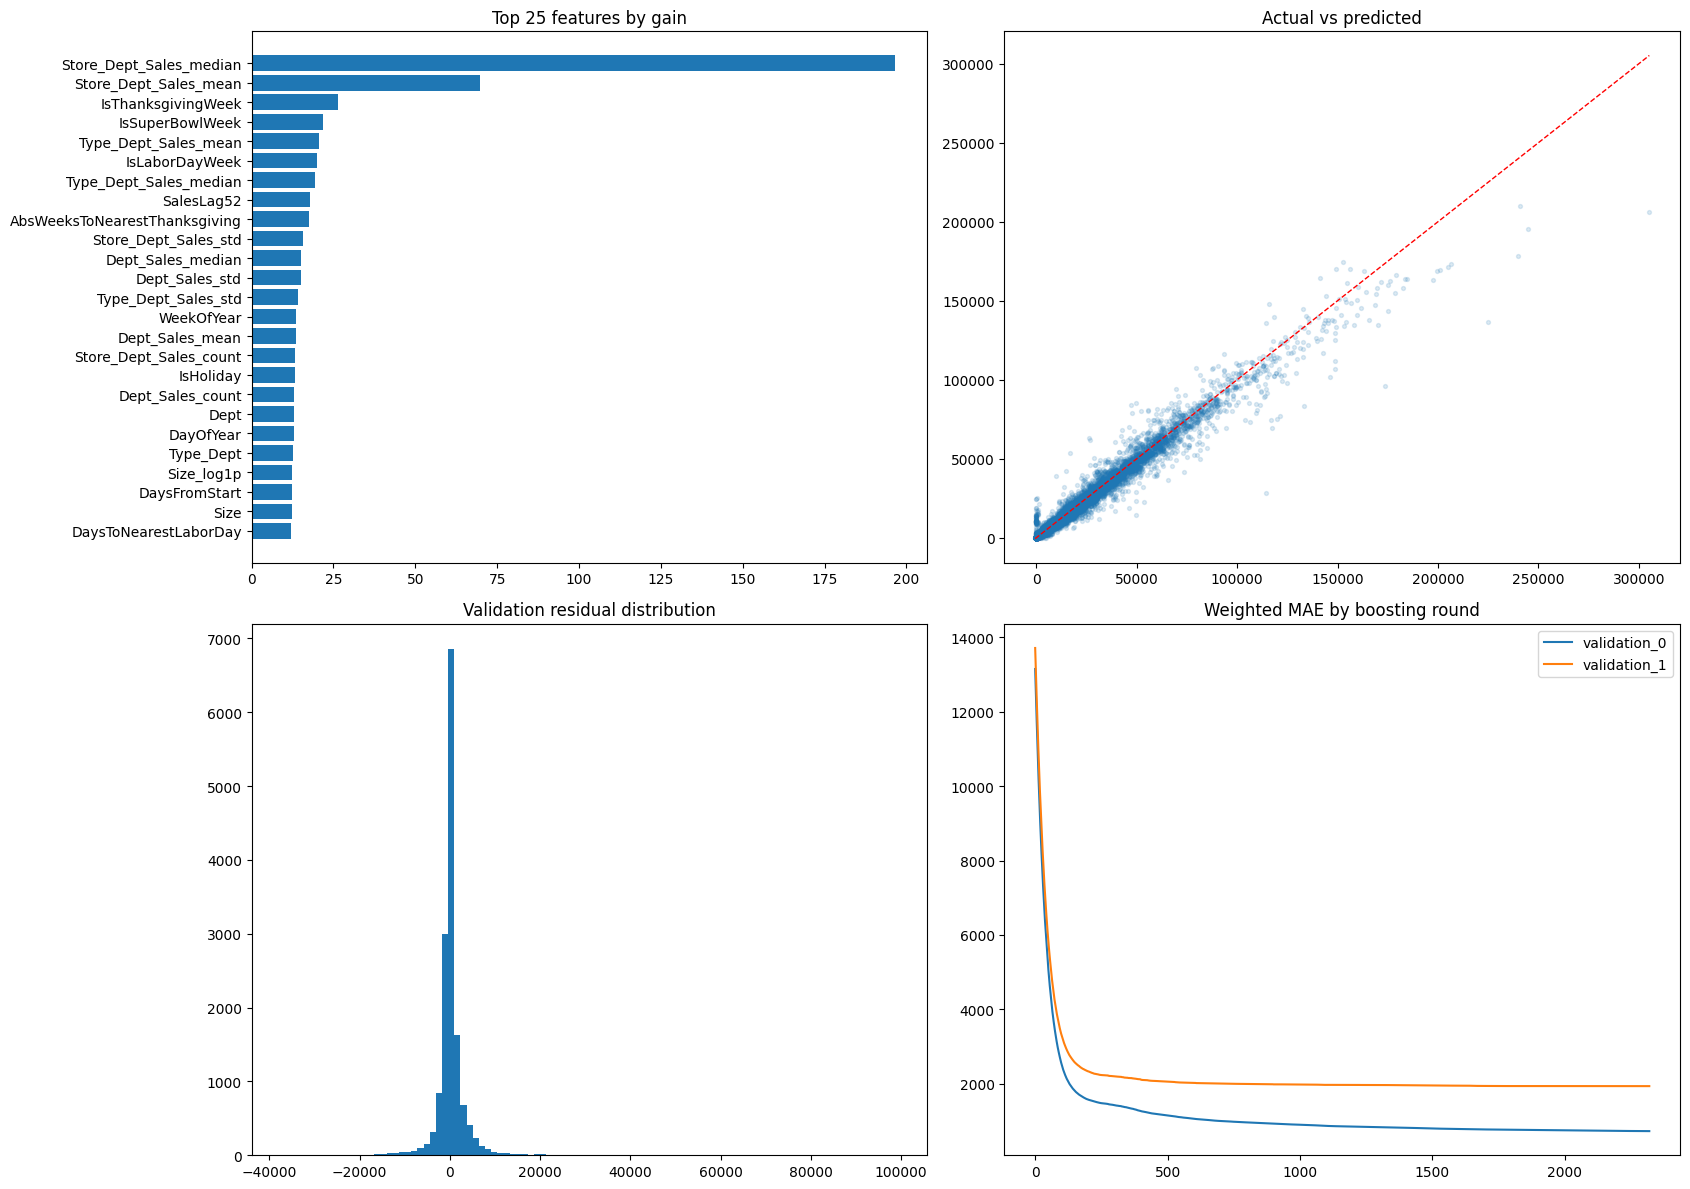

,feature,gain
0,Store_Dept_Sales_median,196.490341
1,Store_Dept_Sales_mean,69.668091
2,IsThanksgivingWeek,26.441399
3,IsSuperBowlWeek,21.794233
4,Type_Dept_Sales_mean,20.693748
5,IsLaborDayWeek,20.125893
6,Type_Dept_Sales_median,19.346035
7,SalesLag52,17.983591
8,AbsWeeksToNearestThanksgiving,17.533075
9,Store_Dept_Sales_std,15.838888


,Dept,wmae,mae,rows
62,77,14549.212726,14041.173264,142.0
60,72,13088.962068,9044.352346,2207.0
37,39,12796.285658,14114.733062,10.0
41,43,12321.193544,12321.193544,7.0
57,65,9136.662201,7996.708287,52.0
73,92,7357.973759,7012.342168,2340.0
36,38,6945.456010,6923.554534,2340.0
6,7,5075.324315,4588.325612,2340.0
4,5,4315.278911,3737.583136,2340.0
76,95,4302.107425,4167.755032,2340.0


In [14]:
validation_results = valid_part[["Store", "Dept", "Date", "IsHoliday", "Weekly_Sales"]].copy()
validation_results["Prediction"] = valid_pred
validation_results["Residual"] = validation_results["Weekly_Sales"] - validation_results["Prediction"]
validation_results["AbsoluteError"] = validation_results["Residual"].abs()
validation_results["Week"] = validation_results["Date"].dt.strftime("%Y-%m-%d")

weekly_metrics = validation_results.groupby("Date").apply(
    lambda g: pd.Series({
        "wmae": weighted_mae(g.Weekly_Sales, g.Prediction, g.IsHoliday),
        "mae": mean_absolute_error(g.Weekly_Sales, g.Prediction),
        "rows": len(g),
    }),
    include_groups=False,
).reset_index()

dept_metrics = validation_results.groupby("Dept").apply(
    lambda g: pd.Series({
        "wmae": weighted_mae(g.Weekly_Sales, g.Prediction, g.IsHoliday),
        "mae": mean_absolute_error(g.Weekly_Sales, g.Prediction),
        "rows": len(g),
    }),
    include_groups=False,
).reset_index().sort_values("wmae", ascending=False)

booster_scores = model.get_booster().get_score(importance_type="gain")
importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "gain": [booster_scores.get(name, 0.0) for name in FEATURE_COLUMNS],
}).sort_values("gain", ascending=False).reset_index(drop=True)

evals = model.evals_result()
learning_curve = pd.DataFrame({
    dataset: values[CONFIG["eval_metric"]] for dataset, values in evals.items()
})
learning_curve.index.name = "boosting_round"
learning_curve = learning_curve.reset_index()

sample = validation_results.sample(min(15000, len(validation_results)), random_state=SEED)
fig, axes = plt.subplots(2, 2, figsize=(17, 12))
top = importance.head(25).sort_values("gain")
axes[0, 0].barh(top.feature, top.gain)
axes[0, 0].set_title("Top 25 features by gain")
axes[0, 1].scatter(sample.Weekly_Sales, sample.Prediction, alpha=0.15, s=8)
limits = [sample[["Weekly_Sales", "Prediction"]].min().min(), sample[["Weekly_Sales", "Prediction"]].max().max()]
axes[0, 1].plot(limits, limits, "r--", linewidth=1)
axes[0, 1].set_title("Actual vs predicted")
axes[1, 0].hist(sample.Residual, bins=100)
axes[1, 0].set_title("Validation residual distribution")
for dataset in [c for c in learning_curve.columns if c != "boosting_round"]:
    axes[1, 1].plot(learning_curve.boosting_round, learning_curve[dataset], label=dataset)
axes[1, 1].set_title("Weighted MAE by boosting round")
axes[1, 1].legend()
plt.tight_layout()

run.log({
    "diagnostics/overview": wandb.Image(fig),
    "diagnostics/feature_importance": wandb.Table(dataframe=importance),
    "diagnostics/weekly_metrics": wandb.Table(dataframe=weekly_metrics),
    "diagnostics/department_metrics": wandb.Table(dataframe=dept_metrics),
    "diagnostics/learning_curve": wandb.Table(dataframe=learning_curve),
    "diagnostics/prediction_sample": wandb.Table(dataframe=sample.assign(Date=sample.Date.astype(str))),
})
plt.show()

display(importance.head(25))
display(dept_metrics.head(15))

## Save and log the reproducible validation bundle

In [15]:
validation_model_path = OUTPUT_DIR / "xgboost_engineered_validation.json"
known_transformer_path = OUTPUT_DIR / "known_feature_transformer.joblib"
aggregate_encoder_path = OUTPUT_DIR / "target_aggregate_encoder.joblib"
importance_path = OUTPUT_DIR / "feature_importance.csv"
metrics_path = OUTPUT_DIR / "validation_metrics.json"
validation_predictions_path = OUTPUT_DIR / "validation_predictions.csv"
config_path = OUTPUT_DIR / "experiment_config.json"

model.save_model(validation_model_path)
joblib.dump(known_transformer, known_transformer_path)
joblib.dump(aggregate_encoder, aggregate_encoder_path)
importance.to_csv(importance_path, index=False)
metrics_path.write_text(json.dumps(metrics, indent=2))
config_path.write_text(json.dumps({**CONFIG, **BEST_PARAMS, **split_summary}, indent=2, default=str))
if CONFIG["log_full_validation_predictions"]:
    validation_results.to_csv(validation_predictions_path, index=False)

model_artifact = wandb.Artifact(
    f"{EXPERIMENT_ID}-validation-model",
    type="model",
    description="Leakage-safe engineered XGBoost model selected by Optuna on a chronological split.",
    metadata={**metrics, **split_summary, "best_params": BEST_PARAMS},
)
for path in [
    validation_model_path, known_transformer_path, aggregate_encoder_path,
    feature_manifest_path, importance_path, metrics_path, config_path,
]:
    model_artifact.add_file(str(path))
if CONFIG["log_full_validation_predictions"]:
    model_artifact.add_file(str(validation_predictions_path))
run.log_artifact(model_artifact, aliases=["validation", "best", "latest"])
run.finish()
print(f"Validation bundle saved to {OUTPUT_DIR}")

baseline/median_wmae,▁
best_iteration,▁
best_score,▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇████
model/best_iteration,▁
model/best_score,▁
validation/holiday_mae,▁
validation/improvement_over_median_pct,▁
validation/mae,▁
validation/non_holiday_mae,▁
+4,...


Validation bundle saved to /content/artifacts/xgboost_engineered


## Optional full-data refit, Kaggle submission, and production-candidate artifact

The full-data refit repeats every fitted preprocessing step on all labeled rows, uses the validation model's best tree count, then predicts the 39-week test horizon. `lag_52` test values are joined only from observed training sales.

In [16]:
if CONFIG["run_final_refit"]:
    final_run = wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name=f"{EXPERIMENT_ID}-full-refit",
        group=EXPERIMENT_ID,
        job_type="full-refit",
        tags=["xgboost", "full-data", "submission", "production-candidate"],
        config={**CONFIG, **BEST_PARAMS, "selected_estimators": int(model.best_iteration) + 1},
        save_code=True,
    )

    final_known_transformer = WalmartKnownFeatureTransformer()
    full_engineered = final_known_transformer.fit_transform(train_merged)
    test_engineered = final_known_transformer.transform(test_merged)
    full_engineered = add_safe_lag_52(full_engineered, train_merged)
    test_engineered = add_safe_lag_52(test_engineered, train_merged)

    final_aggregate_encoder = TimeSafeTargetAggregateEncoder()
    full_engineered = final_aggregate_encoder.fit_transform(
        full_engineered, full_engineered["Weekly_Sales"]
    )
    test_engineered = final_aggregate_encoder.transform(test_engineered)
    X_full, final_features = model_matrix(full_engineered)
    X_test, _ = model_matrix(test_engineered, final_features)
    assert final_features == FEATURE_COLUMNS

    final_rounds = int(model.best_iteration) + 1
    final_model = make_model(
        BEST_PARAMS,
        n_estimators=final_rounds,
        early_stopping=False,
    )
    final_weights = competition_weights(full_engineered["IsHoliday"])
    final_model.fit(
        X_full,
        full_engineered["Weekly_Sales"],
        sample_weight=final_weights,
        verbose=False,
    )
    test_pred = final_model.predict(X_test)
    submission = pd.DataFrame({
        "Id": (
            test_merged["Store"].astype(str) + "_"
            + test_merged["Dept"].astype(str) + "_"
            + test_merged["Date"].dt.strftime("%Y-%m-%d")
        ),
        "Weekly_Sales": test_pred,
    })
    assert len(submission) == len(test_raw)
    assert submission["Id"].is_unique
    assert np.isfinite(submission["Weekly_Sales"]).all()

    final_model_path = OUTPUT_DIR / "xgboost_engineered_final.json"
    final_known_path = OUTPUT_DIR / "final_known_feature_transformer.joblib"
    final_aggregate_path = OUTPUT_DIR / "final_target_aggregate_encoder.joblib"
    submission_path = OUTPUT_DIR / "submission_xgboost_engineered.csv"
    final_model.save_model(final_model_path)
    joblib.dump(final_known_transformer, final_known_path)
    joblib.dump(final_aggregate_encoder, final_aggregate_path)
    submission.to_csv(submission_path, index=False)

    final_run.log({
        "final/training_rows": len(X_full),
        "final/test_rows": len(X_test),
        "final/n_estimators": final_rounds,
        "final/test_lag52_coverage": float(test_engineered["SalesLag52_available"].mean()),
        "final/prediction_mean": float(np.mean(test_pred)),
        "final/prediction_std": float(np.std(test_pred)),
        "final/prediction_min": float(np.min(test_pred)),
        "final/prediction_max": float(np.max(test_pred)),
        "final/submission_sample": wandb.Table(dataframe=submission.head(1000)),
    })
    final_artifact = wandb.Artifact(
        f"{EXPERIMENT_ID}-production-candidate",
        type="model",
        metadata={
            "n_estimators": final_rounds,
            "training_rows": len(X_full),
            "feature_count": len(final_features),
            "test_lag52_coverage": float(test_engineered["SalesLag52_available"].mean()),
            "best_params": BEST_PARAMS,
        },
    )
    for path in [
        final_model_path, final_known_path, final_aggregate_path,
        feature_manifest_path, config_path, submission_path,
    ]:
        final_artifact.add_file(str(path))
    final_run.log_artifact(final_artifact, aliases=["production-candidate", "latest"])
    final_run.finish()
    display(submission.head())
    print(f"Submission saved to {submission_path}")
else:
    print("Final refit skipped. Set CONFIG['run_final_refit'] = True to create a submission.")

final/n_estimators,▁
final/prediction_max,▁
final/prediction_mean,▁
final/prediction_min,▁
final/prediction_std,▁
final/test_lag52_coverage,▁
final/test_rows,▁
final/training_rows,▁
final/n_estimators,2220
final/prediction_max,304905.3125
final/prediction_mean,16176.39062


,Id,Weekly_Sales
0,1_1_2012-11-02,38553.722656
1,1_2_2012-11-02,46184.640625
2,1_3_2012-11-02,9653.529297
3,1_4_2012-11-02,38972.707031
4,1_5_2012-11-02,27289.121094


Submission saved to /content/artifacts/xgboost_engineered/submission_xgboost_engineered.csv


## Outputs

The W&B run group contains data lineage, raw-data and feature-manifest artifacts, one run per Optuna trial, a tuning leaderboard, the selected model's boosting history and diagnostics, serialized preprocessing objects, validation predictions, the model JSON, and—when enabled—the full-data model and Kaggle submission.